## **KLASIFIKASI**

# Klasifikasi Berita Detik.com (SPORT vs FINANCE) dengan Skip-gram dan Naive Bayes

---


1. Muat kembali dataset berita hasil *crawling* (`data_berita_sport_finance.csv`).
2. Lakukan *preprocessing* teks (*cleansing*, *case folding*, *stopword removal*, *stemming*).
3. Bangun representasi vektor kata dengan **Word2Vec metode Skip-gram** (`sg=1`).
4. Ubah setiap berita menjadi **satu vektor dokumen** (rata-rata vektor kata penyusunnya).
5. Lakukan **klasifikasi berita** menggunakan **Naive Bayes**.
6. Evaluasi model (*accuracy*, *precision*, *recall*, *F1-score*, *confusion matrix*, dan *cross-validation*).
7. Bandingkan hasilnya dengan representasi **TF-IDF** dan **PCA** dari tugas sebelumnya.

## Alur Kerja

```
Data CSV -> Preprocessing -> Tokenisasi -> Skip-gram (Word2Vec) -> Vektor Dokumen -> Naive Bayes -> Evaluasi
```

> **Penjelasan cell ini:** Cell ini adalah halaman judul sekaligus instruksi tugas. Tidak ada kode yang dijalankan di sini. Fungsinya memberi gambaran tujuan dan urutan langkah sebelum masuk ke implementasi.

### Import Library

**Penjelasan cell berikutnya:** Semua *library* di-*import* sekali di awal agar rapi.

* `RANDOM_STATE = 42` dipakai di semua proses acak (pembagian data, Word2Vec, *cross-validation*) supaya hasil bisa direproduksi.
* `warnings.filterwarnings("ignore")` menyembunyikan peringatan yang tidak penting agar *output* bersih.
* `nltk.download(...)` mengunduh daftar *stopword* jika belum ada di komputer.

In [3]:
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from gensim.models import Word2Vec

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

warnings.filterwarnings("ignore")
nltk.download('stopwords', quiet=True)

RANDOM_STATE = 42
sns.set_style("whitegrid")
print("Semua library berhasil di-import.")

Semua library berhasil di-import.


## 1. Memuat Dataset

**Penjelasan cell berikutnya:** Dataset hasil *crawling* dibaca dari `data_berita_sport_finance.csv`. Kolom **Judul Berita** dan **Isi Berita** digabung menjadi satu kolom `Teks Mentah` supaya model punya konteks kata yang lebih kaya (sama seperti pada tahap TF-IDF sebelumnya). `fillna('')` mencegah *error* jika ada sel kosong.

Selain itu ditampilkan:

* `df.shape`: jumlah baris dan kolom.
* `value_counts()` dan grafik batang: jumlah berita per kelas. Kelas yang seimbang (sama banyak) membuat akurasi lebih layak dipercaya.

Bentuk dataset: (200, 4)

Distribusi kelas:
Label Kategori
SPORT      100
FINANCE    100
Name: count, dtype: int64


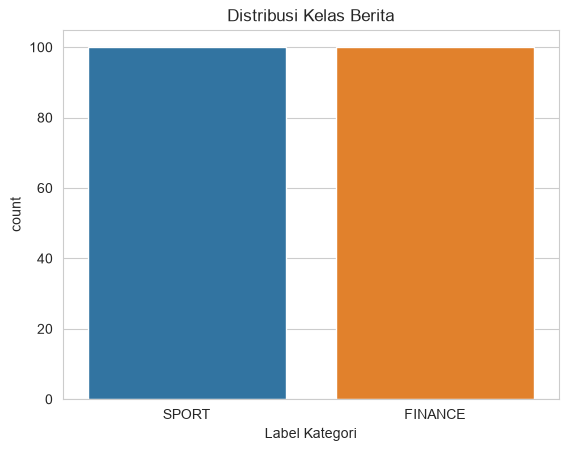

,Label Kategori,Judul Berita,Isi Berita
0,SPORT,"Sempat Ada Banjir, Asian Games 2026 di Jepang ...",Kota Nagoya di Jepang selaku tuan rumah Asian ...
1,SPORT,"Debut di Asian Games, Ubed Tak Sabar Rebut Ema...",Moh. Zaki Ubaidillah akan menjalani debutnya d...
2,SPORT,Men's World Tennis Championship: Rifqi dan Raf...,"Dua petenis Indonesia, Muhammad Rifqi Fitriadi..."
3,SPORT,Kevin Sanjaya Antusias Lihat Semangat Talenta ...,Audisi Umum PB Djarum 2026 sedang berlangsung ...
4,SPORT,Atlet Muda Modern Pentathlon Punya Kesempatan ...,Modern Pentathlon akan dipertandingkan dalam m...


In [4]:
df = pd.read_csv('data_berita_sport_finance.csv')
df['Teks Mentah'] = df['Judul Berita'].fillna('') + ' ' + df['Isi Berita'].fillna('')

print("Bentuk dataset:", df.shape)
print("\nDistribusi kelas:")
print(df['Label Kategori'].value_counts())

sns.countplot(data=df, x='Label Kategori', palette=['#1f77b4', '#ff7f0e'])
plt.title('Distribusi Kelas Berita')
plt.show()

df[['Label Kategori', 'Judul Berita', 'Isi Berita']].head()

## 2. Preprocessing Teks

Skip-gram belajar dari **urutan kata dan konteks sekitar kata**. Artinya, input-nya adalah *daftar kata per dokumen* dan **bukan** matriks TF-IDF (`tfidf_berita.csv`) yang sudah kehilangan urutan kata. File `tfidf_berita.csv` dan `pca_berita.csv` hanya menyimpan angka, sedangkan teks bersihnya tidak tersimpan. Jadi *preprocessing* dijalankan ulang di sini dari data mentah dengan langkah yang sama seperti tugas sebelumnya.

**Penjelasan cell berikutnya:** Cell ini menyiapkan fungsi `bersihkan_teks()` dengan tahapan:

1. **Cleansing:** membuang semua karakter selain huruf (angka dan tanda baca hilang).
2. **Case folding:** mengubah semua huruf menjadi huruf kecil.
3. **Stopword removal:** membuang kata umum (gabungan *stopword* Indonesia, Inggris, dan daftar tambahan khas berita) serta kata satu huruf.
4. **Stemming:** mengembalikan kata ke bentuk dasar dengan Sastrawi (misalnya "menang" dan "kemenangan" menjadi "menang").

In [5]:
stop_words_final = set(stopwords.words('indonesian')).union(set(stopwords.words('english')))
custom_stopwords = {
    'dan','atau','yang','dengan','juga','karena','namun','sehingga','adalah','akan',
    'saat','pada','untuk','dari','oleh','dalam','dapat','kami','mereka','kita','saya',
    'ini','itu','tersebut','tsb','dll','dkk','spt','yg','dgn','dr','jr','sr','thn',
    'tdk','gak','nggak','ya','ia','terkait','berdasarkan','setelah','sebelum',
    'sambil','selain','sekitar','hingga','maupun','bisa','per','waktu','apakah','adanya'
}
stop_words_final |= custom_stopwords
stemmer = StemmerFactory().create_stemmer()

def bersihkan_teks(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'[^a-zA-Z\s]', ' ', text).lower()   # cleansing + case folding
    text = re.sub(r'\s+', ' ', text).strip()
    words = [w for w in text.split() if w not in stop_words_final and len(w) > 1]
    return ' '.join(stemmer.stem(w) for w in words)      # stemming

# Uji fungsi pada satu contoh kalimat
print(bersihkan_teks("Timnas Indonesia memenangkan pertandingan di Asian Games 2026!"))

timnas indonesia menang tanding asi games


### Menerapkan Preprocessing ke Seluruh Data (dengan *Cache*)

**Penjelasan cell berikutnya:** Stemming Sastrawi cukup lambat (sekitar 2-4 menit untuk 200 berita). Agar tidak mengulang setiap kali notebook dijalankan, hasilnya disimpan ke `teks_bersih.csv`.

* Jika file cache **sudah ada** dan jumlah barisnya cocok, hasil dibaca langsung dari file.
* Jika **belum ada**, fungsi `bersihkan_teks()` diterapkan ke semua berita lalu hasilnya disimpan.

Hasilnya masuk ke kolom baru `Teks Bersih`.

In [6]:
CACHE_FILE = 'teks_bersih.csv'

if os.path.exists(CACHE_FILE) and len(pd.read_csv(CACHE_FILE)) == len(df):
    df['Teks Bersih'] = pd.read_csv(CACHE_FILE)['Teks Bersih'].fillna('').values
    print("Teks bersih dimuat dari cache.")
else:
    print("Memproses pembersihan teks (estimasi 2-4 menit)...")
    df['Teks Bersih'] = df['Teks Mentah'].apply(bersihkan_teks)
    df[['Label Kategori', 'Teks Bersih']].to_csv(CACHE_FILE, index=False)
    print("Selesai dan disimpan ke", CACHE_FILE)

df[['Label Kategori', 'Teks Bersih']].head()

Teks bersih dimuat dari cache.


,Label Kategori,Teks Bersih
0,SPORT,banjir asi games jepang aman kota nagoya jepan...
1,SPORT,debut asi games ubed sabar rebut emas regu put...
2,SPORT,men world tennis championship rifqi rafalentin...
3,SPORT,kevin sanjaya antusias lihat semangat talenta ...
4,SPORT,atlet muda modern pentathlon sempat karier mil...


## 3. Tokenisasi

**Penjelasan cell berikutnya:** Word2Vec menerima input berupa **daftar dokumen, dan tiap dokumen adalah daftar kata** (`list of list of str`). Karena teks bersih sudah dipisahkan spasi, tokenisasi cukup memakai `.split()`.

Dokumen yang setelah *preprocessing* menjadi kosong dibuang, karena tidak bisa dijadikan vektor. Lalu dihitung statistik korpus: jumlah dokumen, total token, ukuran kosakata (kata unik), dan rata-rata panjang dokumen.

In [7]:
df['Tokens'] = df['Teks Bersih'].str.split()
df = df[df['Tokens'].str.len() > 0].reset_index(drop=True)

tokenized = df['Tokens'].tolist()
y = df['Label Kategori'].values

total_token = sum(len(t) for t in tokenized)
vocab_unik = len(set(w for t in tokenized for w in t))

print(f"Jumlah dokumen          : {len(tokenized)}")
print(f"Total token             : {total_token}")
print(f"Kosakata unik           : {vocab_unik}")
print(f"Rata-rata token/dokumen : {total_token / len(tokenized):.1f}")
print("\nContoh 15 token pertama dokumen ke-0:", tokenized[0][:15])

Jumlah dokumen          : 200
Total token             : 39025
Kosakata unik           : 4883
Rata-rata token/dokumen : 195.1

Contoh 15 token pertama dokumen ke-0: ['banjir', 'asi', 'games', 'jepang', 'aman', 'kota', 'nagoya', 'jepang', 'tuan', 'rumah', 'asi', 'games', 'terjang', 'banjir', 'ajang']


## 4. Melatih Model Skip-gram (Word2Vec)

**Cara kerja Skip-gram:** Model mengambil satu **kata target** lalu belajar memprediksi **kata-kata konteks** di sekitarnya (*window*). Kata yang sering berada di konteks serupa akan mendapat vektor yang berdekatan. Misalnya kata bertema bursa saham akan berdekatan satu sama lain, dan terpisah dari kata bertema sepak bola.

**Penjelasan cell berikutnya:** Model dilatih dengan parameter berikut.

| Parameter | Nilai | Arti |
|---|---|---|
| `sg` | `1` | Memakai **Skip-gram** (jika `0` berarti CBOW). |
| `vector_size` | `100` | Tiap kata menjadi vektor 100 dimensi. |
| `window` | `5` | Melihat 5 kata ke kiri dan 5 kata ke kanan sebagai konteks. |
| `min_count` | `2` | Kata yang muncul kurang dari 2 kali diabaikan (biasanya *noise*/salah ketik). |
| `negative` | `10` | Jumlah *negative sampling* untuk mempercepat pelatihan. |
| `epochs` | `100` | Jumlah putaran pelatihan. Korpus ini kecil, jadi perlu banyak putaran. |
| `seed`, `workers` | `42`, `1` | Dibuat tetap agar hasil bisa direproduksi. |

> Korpus hanya 200 berita, jadi kualitas vektor kata tidak sekuat model yang dilatih pada jutaan dokumen. Namun untuk membedakan dua topik yang sangat berbeda seperti olahraga dan keuangan, ini biasanya sudah cukup.

In [8]:
VECTOR_SIZE = 100

model_sg = Word2Vec(
    sentences=tokenized,
    vector_size=VECTOR_SIZE,
    window=5,
    min_count=2,
    sg=1,              # 1 = Skip-gram
    negative=10,
    epochs=100,
    seed=RANDOM_STATE,
    workers=1
)

print("Ukuran vocabulary model :", len(model_sg.wv))
print("Dimensi vektor          :", model_sg.wv.vector_size)

Ukuran vocabulary model : 3141
Dimensi vektor          : 100


### Eksplorasi Vektor Kata

**Penjelasan cell berikutnya:** Untuk memeriksa bahwa Skip-gram benar-benar belajar makna, dipilih beberapa kata lalu dicari **5 kata paling mirip** berdasarkan *cosine similarity* vektornya (`most_similar`). Pengecekan `if kata in model_sg.wv` memastikan kata memang ada di kosakata, karena kata yang tidak ada akan menimbulkan *error*. Anda bisa mengganti daftar kata dengan kata lain dari dataset Anda.

In [9]:
kata_uji = ['saham', 'rupiah', 'motogp', 'atlet']

for kata in kata_uji:
    if kata in model_sg.wv:
        mirip = model_sg.wv.most_similar(kata, topn=5)
        print(f"{kata:8s} -> " + ", ".join(f"{k} ({s:.2f})" for k, s in mirip))
    else:
        print(f"{kata:8s} -> tidak ada di vocabulary (coba kata lain)")

saham    -> dividend (0.64), independen (0.63), artikel (0.62), analisis (0.62), rups (0.62)
rupiah   -> rapi (0.63), paman (0.60), akuntabel (0.56), budidaya (0.55), serap (0.54)
motogp   -> aragon (0.59), mandalika (0.58), baby (0.57), marquez (0.56), alien (0.56)
atlet    -> disabilitas (0.53), prestasi (0.50), games (0.49), training (0.49), judo (0.49)


## 5. Membuat Vektor Dokumen

Skip-gram menghasilkan vektor untuk **kata**, sedangkan klasifikasi membutuhkan satu vektor untuk **setiap berita**. Cara paling sederhana adalah **rata-rata (*mean pooling*)** dari semua vektor kata dalam berita tersebut:

$$\vec{d} = \frac{1}{n}\sum_{i=1}^{n}\vec{w_i}$$

**Penjelasan cell berikutnya:** Fungsi `doc_vector()` mengambil vektor tiap kata yang ada di *vocabulary*, lalu merata-ratakannya. Kata yang tidak ada di *vocabulary* (mis. muncul hanya sekali) dilewati. Jika tidak ada satu kata pun yang dikenal, dikembalikan vektor nol. Hasil akhirnya adalah matriks `X` berukuran `(jumlah berita, 100)` dan larik label `y`.

In [10]:
def doc_vector(tokens, wv):
    vecs = [wv[t] for t in tokens if t in wv]
    if not vecs:
        return np.zeros(wv.vector_size)
    return np.mean(vecs, axis=0)

X = np.vstack([doc_vector(tokens, model_sg.wv) for tokens in tokenized])

print("Bentuk X (dokumen x dimensi):", X.shape)
print("Bentuk y                    :", y.shape)
print("Nilai minimum di X          :", round(X.min(), 4), "(ada nilai negatif)")

Bentuk X (dokumen x dimensi): (200, 100)
Bentuk y                    : (200,)
Nilai minimum di X          : -1.1167 (ada nilai negatif)


### Visualisasi Vektor Dokumen (PCA 2D)

**Penjelasan cell berikutnya:** Vektor 100 dimensi tidak bisa digambar langsung, sehingga direduksi ke 2 dimensi dengan PCA hanya untuk **visualisasi**. Setiap titik adalah satu berita, diwarnai menurut kelasnya. Jika titik biru (SPORT) dan oranye (FINANCE) membentuk dua kelompok yang terpisah, artinya vektor Skip-gram sudah cukup membedakan kedua topik, sehingga klasifikasi akan relatif mudah.

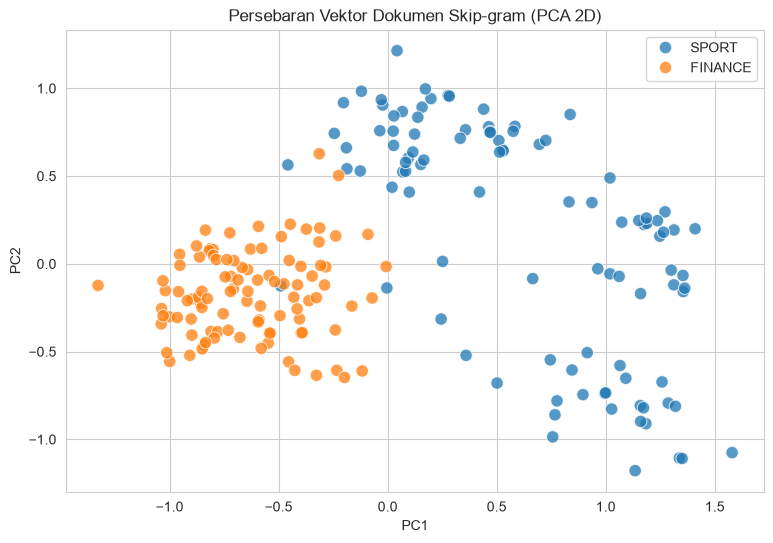

Variansi yang dijelaskan 2 komponen: 23.3%


In [11]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_2d.fit_transform(X)

plt.figure(figsize=(9, 6))
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=y,
                palette={'SPORT': '#1f77b4', 'FINANCE': '#ff7f0e'},
                s=80, alpha=0.75)
plt.title('Persebaran Vektor Dokumen Skip-gram (PCA 2D)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.show()

print(f"Variansi yang dijelaskan 2 komponen: {pca_2d.explained_variance_ratio_.sum():.1%}")

## 6. Pembagian Data Latih dan Uji

**Penjelasan cell berikutnya:** Data dibagi menjadi **80% data latih** (untuk melatih Naive Bayes) dan **20% data uji** (untuk menguji model pada data yang belum pernah dilihat). Parameter penting:

* `stratify=y`: proporsi SPORT dan FINANCE dijaga sama di data latih dan data uji.
* `random_state=42`: pembagian selalu sama setiap dijalankan.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Data latih:", X_train.shape, "| Data uji:", X_test.shape)
print("\nKelas pada data latih:\n", pd.Series(y_train).value_counts())
print("\nKelas pada data uji:\n", pd.Series(y_test).value_counts())

Data latih: (160, 100) | Data uji: (40, 100)

Kelas pada data latih:
 FINANCE    80
SPORT      80
Name: count, dtype: int64

Kelas pada data uji:
 FINANCE    20
SPORT      20
Name: count, dtype: int64


## 7. Klasifikasi dengan Naive Bayes

**Pilihan varian Naive Bayes.** Naive Bayes menerapkan Teorema Bayes dengan asumsi setiap fitur saling bebas:

$$P(C \mid x_1,\dots,x_n) \propto P(C)\prod_{i=1}^{n} P(x_i \mid C)$$

Vektor Skip-gram berisi bilangan **kontinu dan bisa negatif**. Konsekuensinya:

* **`GaussianNB` (dipakai sebagai model utama):** cocok untuk fitur kontinu karena mengasumsikan tiap fitur berdistribusi normal di setiap kelas.
* **`MultinomialNB`:** hanya menerima nilai **non-negatif** (cocok untuk hitungan kata atau TF-IDF). Agar bisa dipakai pada vektor Skip-gram, nilainya perlu diskalakan ke rentang 0-1 dulu. Ini dicoba sebagai pembanding di bagian 9.

**Penjelasan cell berikutnya:** Model `GaussianNB` dibuat, dilatih dengan `fit()` pada data latih, lalu memprediksi kelas data uji dengan `predict()`. Akurasi langsung ditampilkan sebagai gambaran awal.

In [13]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

y_pred = gnb.predict(X_test)
print(f"Akurasi data uji (GaussianNB + Skip-gram): {accuracy_score(y_test, y_pred):.4f}")

Akurasi data uji (GaussianNB + Skip-gram): 0.9750


In [22]:
import joblib
from sklearn.naive_bayes import GaussianNB

# opsional: latih ulang pada seluruh data agar model final memakai semua berita
gnb_final = GaussianNB().fit(X, y)

joblib.dump({'wv': model_sg.wv, 'clf': gnb_final}, 'model_skipgram_nb.pkl')

['model_skipgram_nb.pkl']

## 8. Evaluasi Model

Akurasi saja kurang lengkap, jadi dipakai beberapa metrik:

* **Precision:** dari semua berita yang diprediksi suatu kelas, berapa yang benar.
* **Recall:** dari semua berita yang sebenarnya suatu kelas, berapa yang berhasil ditemukan.
* **F1-score:** rata-rata harmonik precision dan recall.
* **Confusion matrix:** tabel benar/salah prediksi per kelas. Diagonal menunjukkan prediksi benar, di luar diagonal adalah kesalahan.

**Penjelasan cell berikutnya:** `classification_report` mencetak precision, recall, dan F1 per kelas. Setelah itu *confusion matrix* digambar sebagai *heatmap* agar mudah dibaca.

              precision    recall  f1-score   support

     FINANCE     1.0000    0.9500    0.9744        20
       SPORT     0.9524    1.0000    0.9756        20

    accuracy                         0.9750        40
   macro avg     0.9762    0.9750    0.9750        40
weighted avg     0.9762    0.9750    0.9750        40



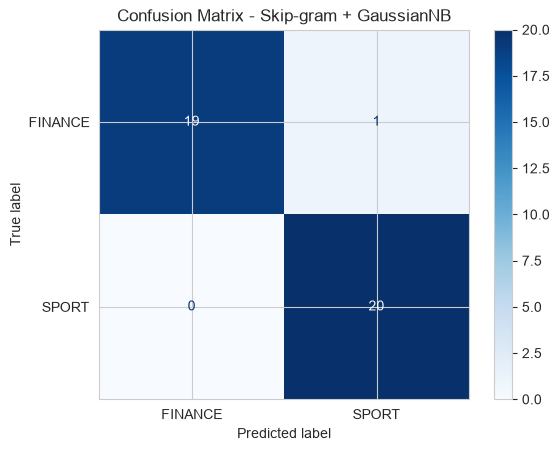

In [15]:
print(classification_report(y_test, y_pred, digits=4))

labels = sorted(set(y))
cm = confusion_matrix(y_test, y_pred, labels=labels)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Skip-gram + GaussianNB')
plt.show()

### Validasi Silang (*Stratified 5-Fold Cross-Validation*)

**Penjelasan cell berikutnya:** Dengan hanya 200 berita, data uji berisi sekitar 40 berita, sehingga satu kali pembagian bisa kebetulan terlalu mudah atau terlalu sulit. *Cross-validation* membagi data menjadi 5 bagian, lalu bergantian tiap bagian dijadikan data uji. Hasilnya dirata-ratakan sehingga estimasi performa lebih stabil. `StratifiedKFold` menjaga proporsi kelas di tiap lipatan, dan `shuffle=True` mengacak data terlebih dulu. Ditampilkan rata-rata dan simpangan baku (±) dari setiap metrik.

In [16]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
metrik = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

cv_gnb = cross_validate(GaussianNB(), X, y, cv=skf, scoring=metrik)

for m in metrik:
    s = cv_gnb['test_' + m]
    print(f"{m:16s}: {s.mean():.4f} (+/- {s.std():.4f})   per-fold: {np.round(s, 3)}")

accuracy        : 0.9750 (+/- 0.0158)   per-fold: [0.975 0.95  0.975 1.    0.975]
precision_macro : 0.9766 (+/- 0.0144)   per-fold: [0.976 0.955 0.976 1.    0.976]
recall_macro    : 0.9750 (+/- 0.0158)   per-fold: [0.975 0.95  0.975 1.    0.975]
f1_macro        : 0.9750 (+/- 0.0159)   per-fold: [0.975 0.95  0.975 1.    0.975]


## 9. Pembanding: MultinomialNB pada Vektor Skip-gram

**Penjelasan cell berikutnya:** `MultinomialNB` tidak bisa menerima nilai negatif, sehingga vektor diskalakan ke rentang 0-1 memakai `MinMaxScaler`. Scaler dan model digabung dalam satu `pipeline` agar di dalam *cross-validation*, scaler hanya belajar dari data latih tiap lipatan. Ini mencegah *data leakage* (bocornya informasi data uji ke proses pelatihan). Hasilnya dibandingkan dengan `GaussianNB`.

In [17]:
pipe_mnb = make_pipeline(MinMaxScaler(), MultinomialNB())
cv_mnb = cross_validate(pipe_mnb, X, y, cv=skf, scoring=metrik)

for m in metrik:
    s = cv_mnb['test_' + m]
    print(f"{m:16s}: {s.mean():.4f} (+/- {s.std():.4f})")

accuracy        : 0.9750 (+/- 0.0158)
precision_macro : 0.9766 (+/- 0.0144)
recall_macro    : 0.9750 (+/- 0.0158)
f1_macro        : 0.9750 (+/- 0.0159)


## 10. Perbandingan dengan TF-IDF dan PCA 

Pada tugas sebelumnya, data direpresentasikan dengan **TF-IDF** (4884 fitur) dan **PCA** (50 komponen). Agar adil, semua representasi dievaluasi dengan skema yang sama: 5-fold *stratified cross-validation*, `random_state` sama, dan model Naive Bayes.

**Penjelasan cell berikutnya:**

1. File `tfidf_berita.csv` dan `pca_berita.csv` dibaca. Kolom `Label Kategori` dipisahkan sebagai target, sisanya menjadi fitur.
2. Beberapa kombinasi dievaluasi dengan fungsi bantu `evaluasi()`: Skip-gram, PCA, dan TF-IDF, masing-masing dengan Naive Bayes yang sesuai. `MultinomialNB` cocok untuk TF-IDF karena nilainya tidak negatif, sedangkan PCA berisi nilai negatif sehingga hanya memakai `GaussianNB`.
3. Semua hasil dirangkum dalam satu tabel dan grafik batang.

In [18]:
df_tfidf = pd.read_csv('tfidf_berita.csv')
df_pca   = pd.read_csv('pca_berita.csv')

X_tfidf, y_tfidf = df_tfidf.drop('Label Kategori', axis=1).values, df_tfidf['Label Kategori'].values
X_pca,   y_pca   = df_pca.drop('Label Kategori', axis=1).values,   df_pca['Label Kategori'].values

def evaluasi(nama, estimator, X_, y_):
    hasil = cross_validate(estimator, X_, y_, cv=skf, scoring=metrik)
    return {
        'Representasi + Model': nama,
        'Jumlah Fitur': X_.shape[1],
        'Accuracy': hasil['test_accuracy'].mean(),
        'Precision': hasil['test_precision_macro'].mean(),
        'Recall': hasil['test_recall_macro'].mean(),
        'F1-macro': hasil['test_f1_macro'].mean(),
    }

rekap = pd.DataFrame([
    evaluasi('Skip-gram + GaussianNB',              GaussianNB(), X, y),
    evaluasi('Skip-gram + MinMax + MultinomialNB',  make_pipeline(MinMaxScaler(), MultinomialNB()), X, y),
    evaluasi('PCA (50 PC) + GaussianNB',            GaussianNB(), X_pca, y_pca),
    evaluasi('TF-IDF + MultinomialNB',              MultinomialNB(), X_tfidf, y_tfidf),
    evaluasi('TF-IDF + GaussianNB',                 GaussianNB(), X_tfidf, y_tfidf),
]).set_index('Representasi + Model')

rekap.round(4)

,Jumlah Fitur,Accuracy,Precision,Recall,F1-macro
Representasi + Model,,,,,
Skip-gram + GaussianNB,100,0.975,0.9766,0.975,0.9750
Skip-gram + MinMax + MultinomialNB,100,0.975,0.9766,0.975,0.9750
PCA (50 PC) + GaussianNB,50,0.915,0.9165,0.915,0.9148
TF-IDF + MultinomialNB,4883,0.975,0.9766,0.975,0.9750
TF-IDF + GaussianNB,4883,0.955,0.9579,0.955,0.9549


### Grafik Perbandingan

**Penjelasan cell berikutnya:** Akurasi dan F1-macro dari tabel di atas digambar sebagai grafik batang horizontal, sehingga terlihat kombinasi mana yang paling baik.

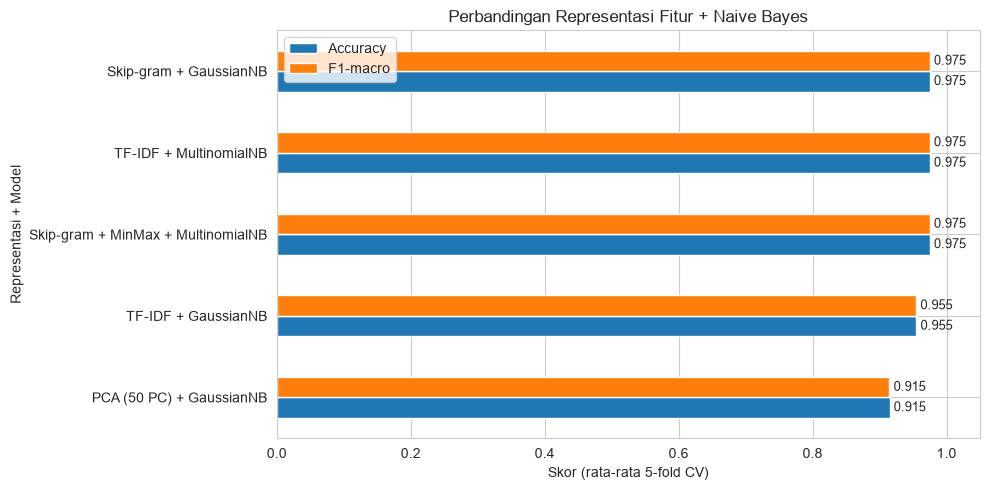

In [19]:
ax = rekap[['Accuracy', 'F1-macro']].sort_values('F1-macro').plot(
    kind='barh', figsize=(10, 5), color=['#1f77b4', '#ff7f0e'])
ax.set_xlim(0, 1.05)
ax.set_xlabel('Skor (rata-rata 5-fold CV)')
ax.set_title('Perbandingan Representasi Fitur + Naive Bayes')
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

## 11. Prediksi Berita Baru

**Penjelasan cell berikutnya:** Cell ini menguji model pada teks berita yang belum pernah dilihat. Alurnya sama dengan data latih:

1. teks dibersihkan dengan `bersihkan_teks()`,
2. dipecah menjadi token,
3. diubah menjadi vektor dokumen dengan `doc_vector()`,
4. diprediksi oleh model `gnb` (yang dilatih pada data latih).

`predict_proba()` menampilkan peluang tiap kelas. Jika tidak ada satu pun kata dari teks yang dikenal model, prediksi dibatalkan karena vektornya akan nol. Silakan ganti contoh teks dengan berita Anda sendiri.

> Peluang dari GaussianNB cenderung *terlalu percaya diri* (mendekati 0 atau 1) karena asumsi independensi fitur, jadi lihat sebagai indikasi kasar saja.

In [20]:
def prediksi_berita(teks, model=gnb):
    tokens = bersihkan_teks(teks).split()
    if not any(t in model_sg.wv for t in tokens):
        return "Tidak dapat diprediksi: tidak ada kata yang dikenal model."
    vec = doc_vector(tokens, model_sg.wv).reshape(1, -1)
    proba = model.predict_proba(vec)[0]
    kelas = model.predict(vec)[0]
    detail = ", ".join(f"{c}: {p:.1%}" for c, p in zip(model.classes_, proba))
    return f"Prediksi: {kelas}  ({detail})"

contoh_berita = [
    "Timnas Indonesia Lolos ke Final Piala Asia setelah Tekuk Jepang 2-1.",
    " Rupiah Menguat ke Level Rp17.894 per Dolar AS.",
    "Timnas Indonesia lolos menang melawan Timnas Singapore Pada hari Sabtu.",
]

for teks in contoh_berita:
    print(teks[:70] + "...")
    print("  ->", prediksi_berita(teks), "\n")

Timnas Indonesia Lolos ke Final Piala Asia setelah Tekuk Jepang 2-1....
  -> Prediksi: SPORT  (FINANCE: 0.0%, SPORT: 100.0%) 

 Rupiah Menguat ke Level Rp17.894 per Dolar AS....
  -> Prediksi: FINANCE  (FINANCE: 100.0%, SPORT: 0.0%) 

Timnas Indonesia lolos menang melawan Timnas Singapore Pada hari Sabtu...
  -> Prediksi: SPORT  (FINANCE: 0.0%, SPORT: 100.0%) 



## 12. Kesimpulan

Isilah kesimpulan berikut **setelah** semua cell dijalankan, dengan angka dari *output* Anda sendiri:

1. **Kualitas representasi Skip-gram.** Lihat hasil `most_similar` dan grafik PCA 2D. Apakah kata-kata yang mirip bertema sama, dan apakah kelas SPORT dan FINANCE terpisah?
2. **Performa Naive Bayes.** Sebutkan akurasi, precision, recall, dan F1 hasil *cross-validation* untuk `GaussianNB`, serta bandingkan dengan `MultinomialNB`.
3. **Perbandingan dengan TF-IDF dan PCA.** Representasi mana yang paling baik pada tabel bagian 10? Berikan alasannya. Sebagai petunjuk: TF-IDF menyimpan kata-kata khas tiap topik secara langsung, sedangkan Skip-gram merangkum makna dan konteks kata dalam dimensi yang jauh lebih kecil.
4. **Keterbatasan.**
   * Korpus hanya 200 berita, sehingga vektor Skip-gram belum sekuat model yang dilatih pada korpus besar.
   * Rata-rata vektor kata mengabaikan urutan kata dan bobot kepentingan kata.
   * Naive Bayes berasumsi fitur saling bebas, padahal dimensi vektor Skip-gram saling berkorelasi.
   * Dua kelas ini topiknya sangat berbeda, jadi skor tinggi belum tentu berlaku untuk kategori yang lebih mirip (misalnya *finance* vs *bisnis*).
5. **Saran pengembangan.** Tambah jumlah data dan kategori, gunakan bobot TF-IDF saat merata-ratakan vektor, atau coba model *pre-trained* (misalnya fastText Bahasa Indonesia).

> **Penjelasan cell ini:** Cell penutup berisi kerangka kesimpulan. Karena angka hasilnya bergantung pada eksekusi di komputer Anda, bagian ini sengaja tidak diisi angka tetap.